<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>LangChain for Generative AI</h1>
<h1>LangGraph</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
from collections import Counter
from pprint import pprint
from operator import itemgetter
from typing import TypedDict, Annotated, Literal

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import Image, display

import openai
from openai import OpenAI

import langchain
import langchain_core
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage, ToolMessage
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate

import langchain_openai
from langchain_openai import ChatOpenAI

import langchain_anthropic
from langchain_anthropic import ChatAnthropic

import langgraph
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent, ToolNode

import watermark

%load_ext watermark
%matplotlib inline

We start by printing out the versions of the libraries we're using for future reference

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.13.3
IPython version      : 9.12.0

Compiler    : Clang 17.0.0 (clang-1700.0.13.3)
OS          : Darwin
Release     : 25.4.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 8c20c848be5682ae23389d07aaf5ae174506efcc

IPython            : 9.12.0
langchain          : 1.2.15
langchain_anthropic: 1.4.1
langchain_core     : 1.3.0
langchain_openai   : 1.1.9
langgraph          : 1.1.8
matplotlib         : 3.10.8
numpy              : 2.4.4
openai             : 1.109.1
pandas             : 2.3.3
watermark          : 2.6.0



Load default figure style

In [3]:
plt.style.use('d4sci.mplstyle')

# LangGraph

LangGraph extends LangChain with a model for building __stateful__, __multi-step__ applications as __graphs__ instead of linear chains.

A LangChain __chain__ is a directed acyclic path: `A | B | C`. It is a perfect fit when each step runs exactly once, in order. But many real applications need something richer:

- __Branching__ — pick a path based on the model's output
- __Cycles__ — retry, refine, or loop until some condition is met
- __Shared state__ — pass structured data between steps, not just a single value
- __Persistence__ — resume a conversation or workflow across invocations

LangGraph models a workflow as a set of __nodes__ (Python functions) connected by __edges__. Each node reads from and writes to a shared __state__ object. Edges can be unconditional or conditional, and the graph is allowed to contain loops.

# State

Every LangGraph graph is parameterized by a `State` schema, typically a `TypedDict`. The schema declares the fields that nodes can read and write.

When two nodes both write to the same field, LangGraph needs to know how to combine the writes. This is the job of a __reducer__. The default reducer simply overwrites, but for message histories we want to __append__. LangGraph provides `add_messages` for exactly this case.

In [4]:
class SimpleState(TypedDict):
    topic: str
    joke: str
    critique: str

# For conversational state, use the add_messages reducer
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# A First Graph

Let's build a minimal two-node graph: one node generates a joke about a topic, a second node critiques it. Each node is just a function that takes the current `State` and returns a dict of updates.

In [5]:
model = ChatOpenAI(model="gpt-4o", temperature=0.7)

In [6]:
def generate_joke(state: SimpleState) -> dict:
    prompt = f"Write a one-line joke about {state['topic']}."
    response = model.invoke(prompt)
    return {"joke": response.content}

def critique_joke(state: SimpleState) -> dict:
    prompt = f"In one sentence, critique this joke: {state['joke']}"
    response = model.invoke(prompt)
    return {"critique": response.content}

We wire the nodes together with edges. `START` and `END` are special sentinels that mark the entry and exit points.

In [7]:
builder = StateGraph(SimpleState)
builder.add_node("generate", generate_joke)
builder.add_node("critique", critique_joke)

builder.add_edge(START, "generate")
builder.add_edge("generate", "critique")
builder.add_edge("critique", END)

graph = builder.compile()

LangGraph can render the compiled graph as a diagram. This is extremely useful for debugging as workflows grow.

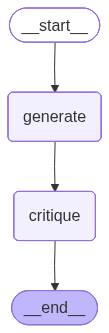

In [8]:
display(Image(graph.get_graph().draw_mermaid_png()))

Invoking the graph runs it end-to-end and returns the final state.

In [9]:
result = graph.invoke({"topic": "data scientists"})
pprint(result)

{'critique': 'The joke is clever in its play on words, but it might fall flat '
             'for those unfamiliar with data science, as it relies on '
             'understanding the metaphorical "high-level insights" in data '
             'analysis.',
 'joke': 'Why did the data scientist bring a ladder to work? To reach the '
         'high-level insights!',
 'topic': 'data scientists'}


# Conditional Edges

Linear flow is useful but not enough. `add_conditional_edges` lets a node's successor be chosen at runtime by a __router function__ that returns the name of the next node.

Here we route a user message to one of three specialized handlers based on its content.

In [10]:
class RouteState(TypedDict):
    question: str
    category: str
    answer: str

def classify(state: RouteState) -> dict:
    prompt = (
        "Classify the following question into exactly one of: "
        "MATH, CODE, OTHER. Respond with just the label.\n\n"
        f"Question: {state['question']}"
    )
    label = model.invoke(prompt).content.strip().upper()
    return {"category": label}

def answer_math(state: RouteState) -> dict:
    r = model.invoke(f"Solve step by step: {state['question']}")
    return {"answer": r.content}

def answer_code(state: RouteState) -> dict:
    r = model.invoke(f"Answer this coding question with a short example:\n{state['question']}")
    return {"answer": r.content}

def answer_other(state: RouteState) -> dict:
    r = model.invoke(state["question"])
    return {"answer": r.content}

The router reads `state['category']` and returns the name of the node to run next.

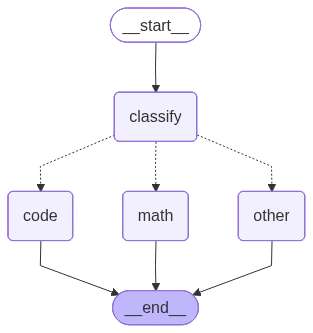

In [11]:
def route(state: RouteState) -> Literal["math", "code", "other"]:
    if "MATH" in state["category"]:
        return "math"
    if "CODE" in state["category"]:
        return "code"
    return "other"

builder = StateGraph(RouteState)
builder.add_node("classify", classify)
builder.add_node("math", answer_math)
builder.add_node("code", answer_code)
builder.add_node("other", answer_other)

builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", route)
builder.add_edge("math", END)
builder.add_edge("code", END)
builder.add_edge("other", END)

router_graph = builder.compile()
display(Image(router_graph.get_graph().draw_mermaid_png()))

In [12]:
for q in ["What is 17 * 23?",
          "How do I reverse a string in Python?",
          "Who wrote Hamlet?"]:
    out = router_graph.invoke({"question": q})
    print(f"[{out['category']}] {q}")
    print(f"  -> {out['answer'][:120]}...\n")

[MATH] What is 17 * 23?
  -> To solve \( 17 \times 23 \) step by step, we can use the standard multiplication algorithm:

1. **Multiply 17 by 3 (the ...

[CODE] How do I reverse a string in Python?
  -> To reverse a string in Python, you can use slicing. Here is a short example:

```python
original_string = "Hello, World!...

[OTHER] Who wrote Hamlet?
  -> Hamlet was written by William Shakespeare....



# Cycles

The feature that truly sets LangGraph apart from chains is __cycles__. A conditional edge can point __back__ to an earlier node, letting the graph iterate until some condition is satisfied.

We'll build a generate-and-refine loop: the model writes a short summary, a critic checks whether it is under a target length, and if not, we loop back and try again (up to a max number of attempts).

In [13]:
class RefineState(TypedDict):
    text: str
    summary: str
    attempts: int
    target_words: int

def summarize(state: RefineState) -> dict:
    feedback = ""
    if state.get("summary"):
        feedback = (
            f"\n\nYour previous attempt was:\n{state['summary']}\n"
            f"It had {len(state['summary'].split())} words. "
            f"Make the next version more concise."
        )
    prompt = (
        f"Summarize the following text in under {state['target_words']} words."
        f"{feedback}\n\nText:\n{state['text']}"
    )
    summary = model.invoke(prompt).content.strip()
    return {"summary": summary, "attempts": state.get("attempts", 0) + 1}

def should_continue(state: RefineState) -> Literal["summarize", "__end__"]:
    word_count = len(state["summary"].split())
    if word_count <= state["target_words"]:
        return END
    if state["attempts"] >= 4:
        return END
    return "summarize"

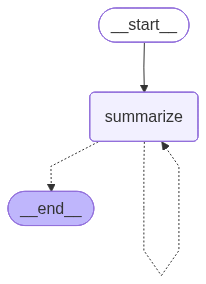

In [14]:
builder = StateGraph(RefineState)
builder.add_node("summarize", summarize)
builder.add_edge(START, "summarize")
builder.add_conditional_edges("summarize", should_continue)

refine_graph = builder.compile()
display(Image(refine_graph.get_graph().draw_mermaid_png()))

Note the self-loop on `summarize`. Each pass either re-enters the node or exits to `END`.

In [15]:
long_text = (
    "LangGraph is a library built on top of LangChain for constructing "
    "stateful, multi-actor applications with large language models. Unlike "
    "linear chains, graphs in LangGraph can contain cycles and branches, "
    "and a shared state object flows through the nodes. This makes it well "
    "suited to building agents, long-running workflows, and any application "
    "that needs to iterate until a condition is met."
)

result = refine_graph.invoke({
    "text": long_text,
    "summary": "",
    "attempts": 0,
    "target_words": 15,
})

print(f"Attempts: {result['attempts']}")
print(f"Summary ({len(result['summary'].split())} words): {result['summary']}")

Attempts: 1
Summary (13 words): LangGraph enhances LangChain for stateful, multi-actor applications using graphs with cycles and branches.


# Tool-Calling Agents

A ReAct agent is a loop: the model decides whether to call a tool, the tool runs, its result is appended to the message history, and the model is called again — until it produces a final answer with no tool call. This is a cycle, so it's a natural fit for LangGraph.

LangGraph ships with a prebuilt `create_react_agent` that wires this up for you. We'll define a couple of toy tools and let the agent pick when to use them.

In [16]:
@tool
def multiply(a: float, b: float) -> float:
    """Multiply two numbers together."""
    return a * b

@tool
def word_count(text: str) -> int:
    """Return the number of words in the given text."""
    return len(text.split())

tools = [multiply, word_count]

/var/folders/lr/j1bs1q851k15cj5y777nxwph0000gn/T/ipykernel_80747/3384827681.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(agent_model, tools)


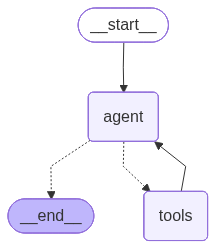

In [17]:
agent_model = ChatAnthropic(model="claude-haiku-4-5-20251001")
agent = create_react_agent(agent_model, tools)

display(Image(agent.get_graph().draw_mermaid_png()))

The agent graph has exactly the cyclic structure we described: `agent → tools → agent → ...` until the model stops requesting tools.

In [18]:
response = agent.invoke({
    "messages": [HumanMessage(content="What is 127 times 53, and how many words are in the sentence 'the quick brown fox'?")]
})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 127 times 53, and how many words are in the sentence 'the quick brown fox'?
================================== Ai Message ==================================

[{'text': "I'll calculate both of those for you.", 'type': 'text'}, {'id': 'toolu_01FJNqLJ99nhkefNg3yqvAsr', 'caller': {'type': 'direct'}, 'input': {'a': 127, 'b': 53}, 'name': 'multiply', 'type': 'tool_use'}, {'id': 'toolu_01SWY6ZxJeiNGHmyZauuUr6S', 'caller': {'type': 'direct'}, 'input': {'text': 'the quick brown fox'}, 'name': 'word_count', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_01FJNqLJ99nhkefNg3yqvAsr)
 Call ID: toolu_01FJNqLJ99nhkefNg3yqvAsr
  Args:
    a: 127
    b: 53
  word_count (toolu_01SWY6ZxJeiNGHmyZauuUr6S)
 Call ID: toolu_01SWY6ZxJeiNGHmyZauuUr6S
  Args:
    text: the quick brown fox
================================= Tool Message =================================
Name: multiply

6731.0
===============================

# Checkpointing and Memory

In LangChain we used `RunnableWithMessageHistory` to keep conversational context. LangGraph replaces this with a more general concept: __checkpointers__.

A checkpointer snapshots the full state of the graph at every step, keyed by a `thread_id`. Re-invoking the graph with the same `thread_id` resumes from where it left off — giving us multi-turn conversations, crash recovery, and time-travel debugging essentially for free.

`MemorySaver` is an in-memory checkpointer suitable for notebooks. For production, swap in the SQLite or Postgres variants.

In [19]:
memory = MemorySaver()
chatbot = create_react_agent(agent_model, tools, checkpointer=memory)

config = {"configurable": {"thread_id": "demo-1"}}

/var/folders/lr/j1bs1q851k15cj5y777nxwph0000gn/T/ipykernel_80747/3420646606.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  chatbot = create_react_agent(agent_model, tools, checkpointer=memory)


In [20]:
r1 = chatbot.invoke(
    {"messages": [HumanMessage(content="Hi, my name is Bruno.")]},
    config=config,
)
print(r1["messages"][-1].content)

Nice to meet you, Bruno! How can I help you today? I have access to tools that can multiply numbers and count words in text if you need those kinds of tasks done.


In [21]:
r2 = chatbot.invoke(
    {"messages": [HumanMessage(content="What is my name?")]},
    config=config,
)
print(r2["messages"][-1].content)

Your name is Bruno!


If we switch to a new `thread_id`, the agent has no recollection — confirming that state is genuinely scoped per thread.

In [22]:
r3 = chatbot.invoke(
    {"messages": [HumanMessage(content="What is my name?")]},
    config={"configurable": {"thread_id": "demo-2"}},
)
print(r3["messages"][-1].content)

I don't have access to information about your name. I can only see the conversation we're having right now, and you haven't told me your name. 

If you'd like to share your name, feel free to tell me! Or if you have other questions I can help with, I'm happy to assist.


# Streaming

For interactive UIs we rarely want to block until the whole graph finishes. `.stream()` yields the state after each node executes, so we can render intermediate progress to the user.

In [23]:
for chunk in refine_graph.stream({
    "text": long_text,
    "summary": "",
    "attempts": 0,
    "target_words": 15,
}):
    for node, update in chunk.items():
        words = len(update.get("summary", "").split())
        print(f"[{node}] attempt {update.get('attempts')}: {words} words")
        print(f"   {update.get('summary', '')}\n")

[summarize] attempt 1: 12 words
   LangGraph enables stateful, multi-actor applications with cycles and branches for complex workflows.



<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px>
</center>